# Predicting Mutual Fund Manager Performance

This notebook studies whether fund type, education, age, and fund tenure help
explain mutual-fund excess returns. It contains the complete code and saved
outputs for Questions 1–11.

The licensed classroom dataset is not included in this repository. To rerun
the notebook, place `case 3.xlsx` or `case 3.xls` in the notebook folder.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from scipy import stats
from statsmodels.stats.diagnostic import (
    het_breuschpagan,
    het_white,
    linear_reset,
)

pd.set_option("display.float_format", lambda value: f"{value:.6f}")

In [2]:
# Load the Data sheet.
data_file = Path("case 3.xlsx")
if not data_file.exists():
    data_file = Path("case 3.xls")

df = pd.read_excel(data_file, sheet_name="Data")
print("Observations:", len(df))
print("Variables:", ", ".join(df.columns))

Observations: 540
Variables: RET, GRI, SAT, MBA, AGE, TEN


## Question 1 — Original regression and model validity

A low R-squared does not automatically make a regression useless. Fund returns
contain substantial unpredictable variation, while statistically significant
coefficients can still identify systematic relationships. Conversely, two
unrelated trending time series can produce a misleadingly high R-squared.

In [3]:
# Original regression from Table 1
y = df["RET"]
X_full = sm.add_constant(df[["GRI", "SAT", "MBA", "AGE", "TEN"]])
full_model = sm.OLS(y, X_full).fit()

full_table = pd.DataFrame({
    "Coefficient": full_model.params,
    "Standard error": full_model.bse,
    "t-statistic": full_model.tvalues,
    "p-value": full_model.pvalues,
})
display(full_table)

regression_se = np.sqrt(full_model.mse_resid)
beta_weights = (
    full_model.params[["GRI", "SAT", "MBA", "AGE", "TEN"]]
    * df[["GRI", "SAT", "MBA", "AGE", "TEN"]].std()
    / df["RET"].std()
)

reset_full = linear_reset(full_model, power=2, use_f=True)
bp_full = het_breuschpagan(full_model.resid, full_model.model.exog)
white_full = het_white(full_model.resid, full_model.model.exog)

print("Standard error of regression:", round(regression_se, 6))
print("R-squared:", round(full_model.rsquared, 6))
print("Adjusted R-squared:", round(full_model.rsquared_adj, 6))
print("\nStandardized beta weights:")
display(beta_weights.rename("Beta weight").to_frame())
print("RESET p-value:", round(float(reset_full.pvalue), 6))
print("Breusch-Pagan p-value:", round(bp_full[3], 6))
print("White-test p-value:", round(white_full[3], 6))
print("Conclusion: linearity is not rejected, but equal variance is rejected.")

,Coefficient,Standard error,t-statistic,p-value
const,-2.642159,3.346531,-0.789522,0.430157
GRI,-2.110461,0.738858,-2.856383,0.004452
SAT,0.005735,0.002660,2.156289,0.031507
MBA,-0.180647,0.756644,-0.238748,0.811393
AGE,-0.068893,0.041818,-1.647446,0.100055
TEN,-0.118722,0.083502,-1.421780,0.155674


Standard error of regression: 8.354658
R-squared: 0.043349
Adjusted R-squared: 0.034391

Standardized beta weights:


,Beta weight
GRI,-0.121429
SAT,0.093685
MBA,-0.010321
AGE,-0.080117
TEN,-0.069108


RESET p-value: 0.24261
Breusch-Pagan p-value: 0.003145
White-test p-value: 0.001235
Conclusion: linearity is not rejected, but equal variance is rejected.


## Question 2 — Bob and Putney predictions

In [4]:
current_candidates = pd.DataFrame(
    {
        "const": [1, 1],
        "GRI": [1, 1],
        "SAT": [1042, 1355],
        "MBA": [0, 1],
        "AGE": [35, 32],
        "TEN": [5, 2],
    },
    index=["Bob", "Putney"],
)

current_predictions = full_model.predict(current_candidates)
print("Current-fund predicted RET:")
display(current_predictions.rename("Predicted RET").to_frame())
print("Putney minus Bob:", round(current_predictions["Putney"] - current_predictions["Bob"], 4))

hired_candidates = current_candidates.copy()
hired_candidates["TEN"] = 0
hired_predictions = full_model.predict(hired_candidates)

print("\nPredicted RET if hired by AMBTPM:")
display(hired_predictions.rename("Predicted RET").to_frame())
print("Putney minus Bob:", round(hired_predictions["Putney"] - hired_predictions["Bob"], 4))

Current-fund predicted RET:


,Predicted RET
Bob,-1.781809
Putney,0.395378


Putney minus Bob: 2.1772

Predicted RET if hired by AMBTPM:


,Predicted RET
Bob,-1.188201
Putney,0.632822


Putney minus Bob: 1.821


## Question 3 — One-sided hypothesis tests

In [5]:
# 3(a): Princeton SAT minus Ohio State SAT
sat_difference = 1355 - 1042
princeton_effect = sat_difference * full_model.params["SAT"]
princeton_se = sat_difference * full_model.bse["SAT"]
princeton_t = princeton_effect / princeton_se
princeton_p = stats.t.sf(princeton_t, full_model.df_resid)

print("3(a) Estimated Princeton increase:", round(princeton_effect, 4))
print("t-statistic:", round(princeton_t, 4))
print("One-sided p-value:", round(princeton_p, 6))
print("Significant at 5%:", princeton_p < 0.05)

# 3(b): switching from GRI=1 to GRI=0
growth_effect = -full_model.params["GRI"]
growth_t = (growth_effect - 1) / full_model.bse["GRI"]
growth_p = stats.t.sf(growth_t, full_model.df_resid)

print("\n3(b) Estimated increase from switching to growth:", round(growth_effect, 4))
print("t-statistic for increase greater than 1%:", round(growth_t, 4))
print("One-sided p-value:", round(growth_p, 6))
print("Significant at 10%:", growth_p < 0.10)

3(a) Estimated Princeton increase: 1.795
t-statistic: 2.1563
One-sided p-value: 0.015753
Significant at 5%: True

3(b) Estimated increase from switching to growth: 2.1105
t-statistic for increase greater than 1%: 1.5029
One-sided p-value: 0.066723
Significant at 10%: True


## Question 4 — MBA interpretation

The MBA coefficient is compared while holding fund type, undergraduate-school
SAT, age, and tenure constant. If non-MBA managers hold higher-beta portfolios
and beta raises expected returns, omitting beta biases the MBA coefficient
downward. Adding beta should move it upward.

In [6]:
print("MBA coefficient:", round(full_model.params["MBA"], 6))
print("MBA p-value:", round(full_model.pvalues["MBA"], 6))
print("Conclusion: there is no strong evidence that MBA managers perform worse.")

MBA coefficient: -0.180647
MBA p-value: 0.811393
Conclusion: there is no strong evidence that MBA managers perform worse.


## Question 5 — Age and survivorship bias

Survivorship bias exaggerates the negative AGE effect because unsuccessful
young managers leave the observed sample more quickly, whereas experienced
managers may survive one or two poor years.

In [7]:
print("AGE coefficient:", round(full_model.params["AGE"], 6))
print("Lowest significance level:", round(100 * full_model.pvalues["AGE"], 3), "%")

AGE coefficient: -0.068893
Lowest significance level: 10.005 %


## Question 6 — Streamlined regression

In [8]:
# Keep variables significant at the 15% level: GRI, SAT, and AGE
X_simple = sm.add_constant(df[["GRI", "SAT", "AGE"]])
simple_model = sm.OLS(y, X_simple).fit()

simple_table = pd.DataFrame({
    "Coefficient": simple_model.params,
    "Standard error": simple_model.bse,
    "t-statistic": simple_model.tvalues,
    "p-value": simple_model.pvalues,
})
display(simple_table)

reset_simple = linear_reset(simple_model, power=2, use_f=True)
bp_simple = het_breuschpagan(simple_model.resid, simple_model.model.exog)
white_simple = het_white(simple_model.resid, simple_model.model.exog)

print(
    f"RET = {simple_model.params['const']:.6f} "
    f"{simple_model.params['GRI']:+.6f}*GRI "
    f"{simple_model.params['SAT']:+.6f}*SAT "
    f"{simple_model.params['AGE']:+.6f}*AGE"
)
print("RESET p-value:", round(float(reset_simple.pvalue), 6))
print("Breusch-Pagan p-value:", round(bp_simple[3], 6))
print("White-test p-value:", round(white_simple[3], 6))

age_change = simple_model.params["AGE"] - full_model.params["AGE"]
age_ten_correlation = df["AGE"].corr(df["TEN"])
print("\nOld AGE coefficient:", round(full_model.params["AGE"], 6))
print("New AGE coefficient:", round(simple_model.params["AGE"], 6))
print("Change:", round(age_change, 6))
print("Correlation between AGE and TEN:", round(age_ten_correlation, 4))
print("AGE becomes more negative because AGE and TEN are positively related and TEN has a negative coefficient.")

,Coefficient,Standard error,t-statistic,p-value
const,-2.583922,3.340350,-0.773548,0.439539
GRI,-2.111005,0.738580,-2.858195,0.004426
SAT,0.006242,0.002593,2.406971,0.016423
AGE,-0.095959,0.036555,-2.625046,0.008911


RET = -2.583922 -2.111005*GRI +0.006242*SAT -0.095959*AGE
RESET p-value: 0.105607
Breusch-Pagan p-value: 0.020022
White-test p-value: 0.004053

Old AGE coefficient: -0.068893
New AGE coefficient: -0.095959
Change: -0.027066
Correlation between AGE and TEN: 0.4698
AGE becomes more negative because AGE and TEN are positively related and TEN has a negative coefficient.


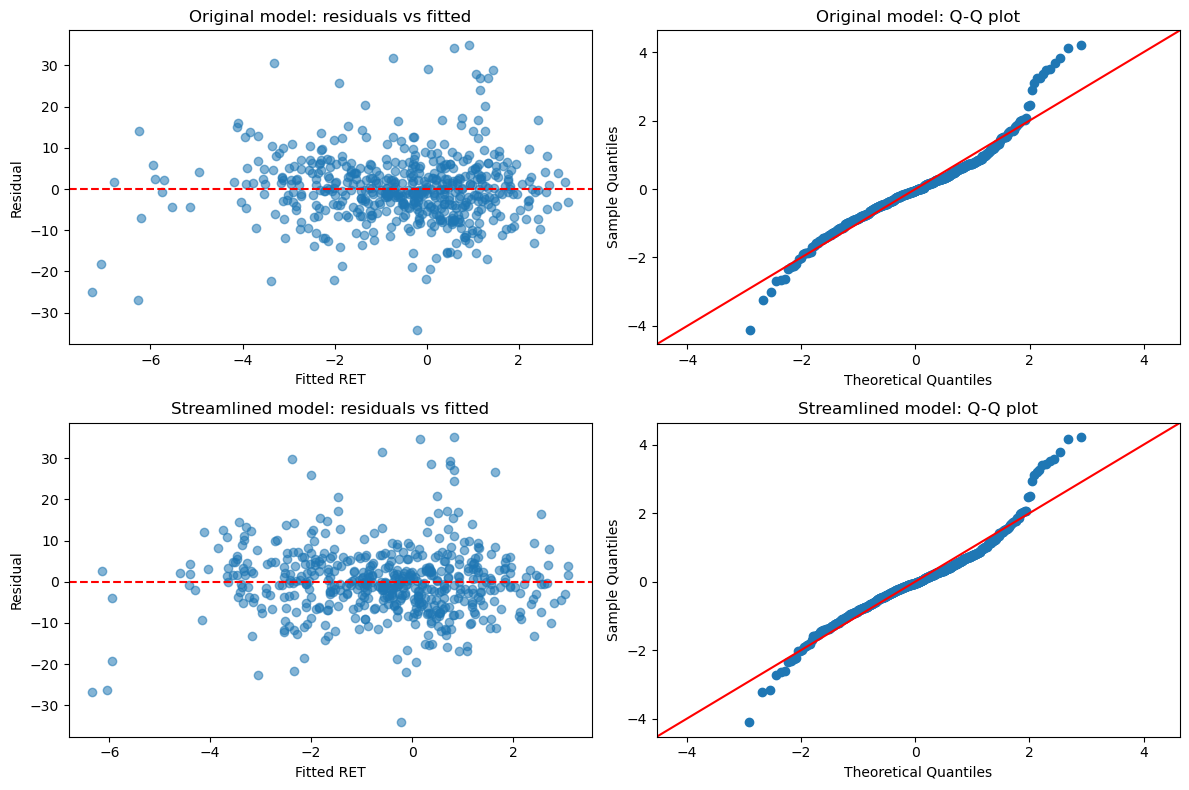

In [9]:
# Diagnostic plots for the original and streamlined models
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (title, model) in enumerate([
    ("Original model", full_model),
    ("Streamlined model", simple_model),
]):
    axes[row, 0].scatter(model.fittedvalues, model.resid, alpha=0.55)
    axes[row, 0].axhline(0, color="red", linestyle="--")
    axes[row, 0].set_title(f"{title}: residuals vs fitted")
    axes[row, 0].set_xlabel("Fitted RET")
    axes[row, 0].set_ylabel("Residual")
    sm.qqplot(model.resid, line="45", fit=True, ax=axes[row, 1])
    axes[row, 1].set_title(f"{title}: Q-Q plot")

plt.tight_layout()
plt.show()

## Question 7 — Comparing fund types

In [10]:
growth = df.loc[df["GRI"] == 0, "RET"]
growth_income = df.loc[df["GRI"] == 1, "RET"]

X_fund_type = sm.add_constant(df[["GRI"]])
fund_type_model = sm.OLS(df["RET"], X_fund_type).fit()
fund_type_robust = fund_type_model.get_robustcov_results(cov_type="HC1")

fund_summary = pd.DataFrame({
    "Fund type": ["Growth", "Growth and income"],
    "Observations": [len(growth), len(growth_income)],
    "Mean RET": [growth.mean(), growth_income.mean()],
    "Standard deviation": [growth.std(), growth_income.std()],
})
display(fund_summary)

levene_test = stats.levene(growth, growth_income, center="mean")
welch_test = stats.ttest_ind(growth, growth_income, equal_var=False)

print("Difference, GRI=1 minus GRI=0:", round(fund_type_model.params["GRI"], 4))
print("Classical p-value:", round(fund_type_model.pvalues["GRI"], 6))
print("HC1 robust p-value:", round(fund_type_robust.pvalues[1], 6))
print("Levene equal-variance p-value:", round(levene_test.pvalue, 6))
print("Welch t-test p-value:", round(welch_test.pvalue, 6))
print("Conclusion: growth funds have higher average RET, and equal variance is rejected.")

,Fund type,Observations,Mean RET,Standard deviation
0,Growth,327,0.395924,8.936684
1,Growth and income,213,-1.915927,7.597539


Difference, GRI=1 minus GRI=0: -2.3119
Classical p-value: 0.001951
HC1 robust p-value: 0.001354
Levene equal-variance p-value: 0.020515
Welch t-test p-value: 0.001361
Conclusion: growth funds have higher average RET, and equal variance is rejected.


## Question 8 — New Princeton growth fund

In [11]:
# Use growth funds and known prospectus characteristics: SAT and TEN
growth_data = df[df["GRI"] == 0]
X_growth = sm.add_constant(growth_data[["SAT", "TEN"]])
growth_model = sm.OLS(growth_data["RET"], X_growth).fit()

new_growth_fund = pd.DataFrame({"const": [1], "SAT": [1355], "TEN": [0]})
prediction = growth_model.get_prediction(new_growth_fund)
prediction_table = prediction.summary_frame(alpha=0.05)

estimated_ret = prediction_table.loc[0, "mean"]
mean_se = prediction_table.loc[0, "mean_se"]
individual_se = np.sqrt(growth_model.mse_resid + mean_se**2)
probability_above_zero = stats.t.sf(
    (0 - estimated_ret) / individual_se,
    growth_model.df_resid,
)
probability_above_1_5 = stats.t.sf(
    (1.5 - estimated_ret) / mean_se,
    growth_model.df_resid,
)

reset_growth = linear_reset(growth_model, power=2, use_f=True)
bp_growth = het_breuschpagan(growth_model.resid, growth_model.model.exog)
white_growth = het_white(growth_model.resid, growth_model.model.exog)

print("RESET p-value:", round(float(reset_growth.pvalue), 6))
print("Breusch-Pagan p-value:", round(bp_growth[3], 6))
print("White-test p-value:", round(white_growth[3], 6))
print("Estimated RET:", round(estimated_ret, 4))
print(
    "95% individual prediction interval:",
    round(prediction_table.loc[0, "obs_ci_lower"], 4),
    "to",
    round(prediction_table.loc[0, "obs_ci_upper"], 4),
)
print("Individual prediction SE:", round(individual_se, 4))
print("Probability one fund beats the market:", round(probability_above_zero, 4))
print("Mean-response SE:", round(mean_se, 4))
print("Probability diversified portfolio exceeds 1.5%:", round(probability_above_1_5, 4))

RESET p-value: 0.385365
Breusch-Pagan p-value: 0.688401
White-test p-value: 0.93483
Estimated RET: 2.3704
95% individual prediction interval: -15.1931 to 19.9339
Individual prediction SE: 8.9277
Probability one fund beats the market: 0.6046
Mean-response SE: 0.9653
Probability diversified portfolio exceeds 1.5%: 0.8161


## Question 9 — Effect of a larger sample

A larger random sample reduces coefficient and mean-response standard errors,
so the estimated return in 8(a) stabilizes and the portfolio probability in
8(c) becomes more precise. The individual-fund prediction error in 8(b) falls
much less because unpredictable fund-specific variation remains.

## Question 10 — Conditional differences in manager age

In [12]:
# AGE is the dependent variable in Question 10
X_age = sm.add_constant(df[["GRI", "SAT", "MBA", "TEN"]])
age_model = sm.OLS(df["AGE"], X_age).fit()

reset_age = linear_reset(age_model, power=2, use_f=True)
bp_age = het_breuschpagan(age_model.resid, age_model.model.exog)
white_age = het_white(age_model.resid, age_model.model.exog)

# White test rejects equal variance, so use HC1 robust standard errors
age_robust = age_model.get_robustcov_results(cov_type="HC1")
variable_names = age_model.model.exog_names
gri_position = variable_names.index("GRI")
mba_position = variable_names.index("MBA")

robust_age_table = pd.DataFrame({
    "Coefficient": age_robust.params,
    "HC1 standard error": age_robust.bse,
    "t-statistic": age_robust.tvalues,
    "Two-sided p-value": age_robust.pvalues,
}, index=variable_names)
display(robust_age_table)

gri_t = age_robust.tvalues[gri_position]
gri_one_sided_p = stats.t.sf(gri_t, age_model.df_resid)
mba_80_interval = age_robust.conf_int(alpha=0.20)[mba_position]

print("RESET p-value:", round(float(reset_age.pvalue), 6))
print("Breusch-Pagan p-value:", round(bp_age[3], 6))
print("White-test p-value:", round(white_age[3], 6))
print("\n10(a) GRI coefficient:", round(age_model.params["GRI"], 4))
print("One-sided robust p-value:", round(gri_one_sided_p, 6))
print("Growth-and-income managers are older at 5%:", gri_one_sided_p < 0.05)
print("\n10(b) MBA coefficient:", round(age_model.params["MBA"], 4))
print(
    "Robust 80% confidence interval:",
    round(mba_80_interval[0], 4),
    "to",
    round(mba_80_interval[1], 4),
)
print("Conclusion: otherwise comparable MBA managers are younger on average.")

,Coefficient,HC1 standard error,t-statistic,Two-sided p-value
const,32.186084,2.983912,10.786540,0.000000
GRI,1.424150,0.771840,1.845136,0.065570
SAT,0.007759,0.002675,2.900349,0.003881
MBA,-1.879255,0.793397,-2.368620,0.018209
TEN,0.942057,0.069702,13.515494,0.000000


RESET p-value: 0.539629
Breusch-Pagan p-value: 0.056225
White-test p-value: 0.012919

10(a) GRI coefficient: 1.4242
One-sided robust p-value: 0.032785
Growth-and-income managers are older at 5%: True

10(b) MBA coefficient: -1.8793
Robust 80% confidence interval: -2.8973 to -0.8612
Conclusion: otherwise comparable MBA managers are younger on average.


## Question 11 — Recommendation

The model-based recommendation is Putney because her predicted RET is higher.
However, the low R-squared and wide individual prediction uncertainty mean the
evidence should be treated as modest rather than decisive.

In [13]:
putney_advantage = hired_predictions["Putney"] - hired_predictions["Bob"]
print("Putney predicted advantage:", round(putney_advantage, 4), "percentage points")
print("Recommendation: Putney, with caution because individual returns remain highly uncertain.")

Putney predicted advantage: 1.821 percentage points
Recommendation: Putney, with caution because individual returns remain highly uncertain.
